In [1]:
import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pyarrow"])


Kernel Python: /Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [65]:
import sys, pkgutil, platform
print("Kernel Python:", sys.executable)
!which python
!python --version
!pip --version
print("pyarrow found? ->", pkgutil.find_loader("pyarrow") is not None)


Kernel Python: /Library/Developer/CommandLineTools/usr/bin/python3
/Users/mariaoros/miniconda3/bin/python
Python 3.13.5
pip 25.1 from /Users/mariaoros/miniconda3/lib/python3.13/site-packages/pip (python 3.13)
pyarrow found? -> True


In [67]:
!conda activate base
!python -m ipykernel install --user --name base-pyarrow --display-name "Python (base + pyarrow)"



CondaError: Run 'conda init' before 'conda activate'

/Users/mariaoros/miniconda3/bin/python: No module named ipykernel


## Data Exploration

In [2]:
import pandas as pd
import seaborn as sns


In [3]:
df = pd.read_csv('../1_Data/exit_velo_project_data.csv')
display(df.head())

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
0,2023,mlb,235,1335,95.7352,47.2362,-6.4422,6.4960,fly_ball,R,R,72,FB,out,32.8
1,2023,mlb,3182,1335,95.9380,4.7291,-4.8052,0.7806,ground_ball,L,R,75,OS,out,29.2
2,2023,mlb,3856,1988,89.1404,-16.2251,15.2382,0.0311,ground_ball,S,R,72,OS,out,29.7
3,2023,mlb,2017,1988,88.7278,-6.8385,-11.5988,0.1215,ground_ball,R,R,69,BB,out,23.4
4,2023,mlb,1594,1988,89.2888,0.5079,-22.1899,0.3802,ground_ball,R,R,73,FB,out,35.3


In [4]:
df.describe() #there is a number of missing values in data

,season,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,batter_height,age
count,1.344651e+06,1.344651e+06,1.344651e+06,1.246672e+06,1.335521e+06,1.338424e+06,1.268683e+06,1.344651e+06,1.344651e+06
mean,2.021209e+03,2.052400e+03,2.252539e+03,8.800986e+01,1.257956e+01,-1.191746e+00,2.437670e+00,7.216905e+01,2.694484e+01
std,1.495155e+00,1.204682e+03,1.301185e+03,1.448905e+01,2.795453e+01,2.439452e+01,2.230315e+00,2.264593e+00,3.489235e+00
min,2.019000e+03,2.000000e+00,1.000000e+00,2.607800e+00,-8.968410e+01,-1.799150e+02,0.000000e+00,6.500000e+01,1.710000e+01
25%,2.019000e+03,9.700000e+02,1.136000e+03,7.975270e+01,-6.181000e+00,-1.837794e+01,1.617000e-01,7.100000e+01,2.450000e+01
50%,2.021000e+03,2.079000e+03,2.271000e+03,9.083820e+01,1.287110e+01,-1.330800e+00,1.906800e+00,7.200000e+01,2.630000e+01
75%,2.022000e+03,3.116000e+03,3.368000e+03,9.879510e+01,3.068720e+01,1.559262e+01,4.577800e+00,7.400000e+01,2.890000e+01
max,2.023000e+03,4.128000e+03,4.490000e+03,1.453188e+02,8.987520e+01,1.799618e+02,9.922500e+00,8.300000e+01,4.300000e+01


In [4]:
df.dtypes

season             int64
level_abbr        object
batter_id          int64
pitcher_id         int64
exit_velo        float64
launch_angle     float64
spray_angle      float64
hangtime         float64
hit_type          object
batter_hand       object
pitcher_hand      object
batter_height      int64
pitch_group       object
outcome           object
age              float64
dtype: object

In [27]:
df.batter_height.describe()

count    1.344651e+06
mean     7.216905e+01
std      2.264593e+00
min      6.500000e+01
25%      7.100000e+01
50%      7.200000e+01
75%      7.400000e+01
max      8.300000e+01
Name: batter_height, dtype: float64

In [7]:
df.columns

Index(['season', 'level_abbr', 'batter_id', 'pitcher_id', 'exit_velo',
       'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand',
       'pitcher_hand', 'batter_height', 'pitch_group', 'outcome', 'age'],
      dtype='object')

In [ ]:
## Outcome variable
# 'exit_velo',

## Level of granularity
# 'season', 'level_abbr', 'batter_id',

## Predictive variables
# 'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand', 'pitcher_hand', 'batter_height', 'pitch_group',  'age'

## Not predictive
# 'pitcher_id',
# no directly the outcome but related to the outcome

In [17]:
set(df['pitch_group'].values)

{'BB', 'FB', 'OS'}

In [18]:
set(df['outcome'].values)


{'double', 'home_run', 'out', 'single', 'triple'}

In [19]:
set(df['batter_hand'].values)


{'L', 'R', 'S'}

In [20]:
set(df['hit_type'].values)

{'bunt', 'fly_ball', 'ground_ball', 'line_drive', nan, 'pop_up'}

### Exploring Continuous Variables

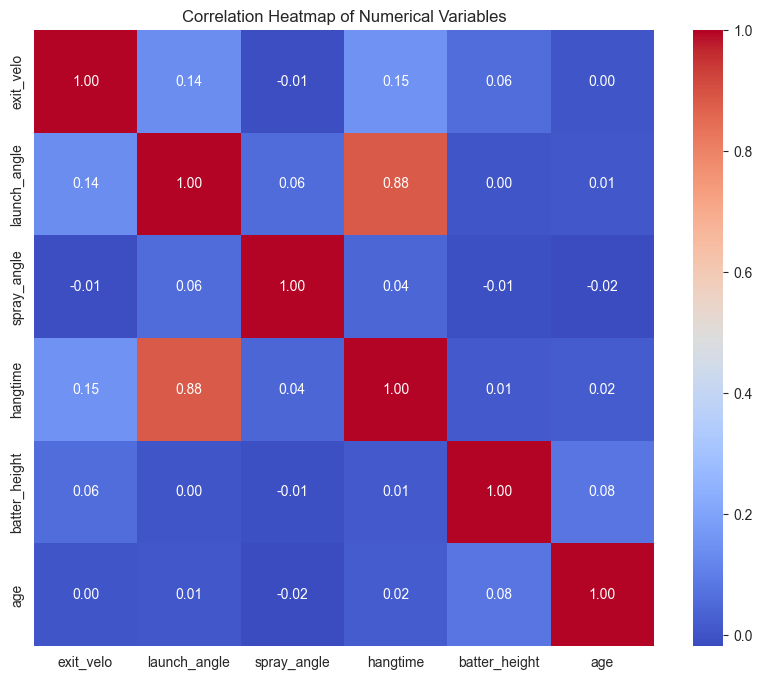

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'launch_angle', 'spray_angle', 'hangtime', 'batter_height', 'age'
# 'hit_type', 'batter_hand', 'pitcher_hand', 'pitch_group',
numerical_df = df[['exit_velo','launch_angle', 'spray_angle', 'hangtime','batter_height','age']]
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [32]:
df[('exit_velo')].describe()

count    1.246672e+06
mean     8.800986e+01
std      1.448905e+01
min      2.607800e+00
25%      7.975270e+01
50%      9.083820e+01
75%      9.879510e+01
max      1.453188e+02
Name: exit_velo, dtype: float64

<Axes: >

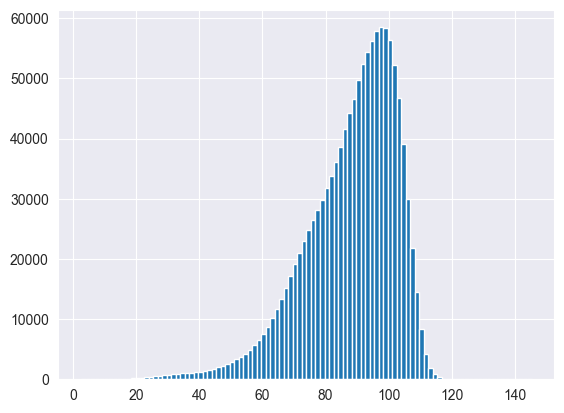

In [25]:
## Distribution of exit velocity
df[('exit_velo')].hist(bins=100)

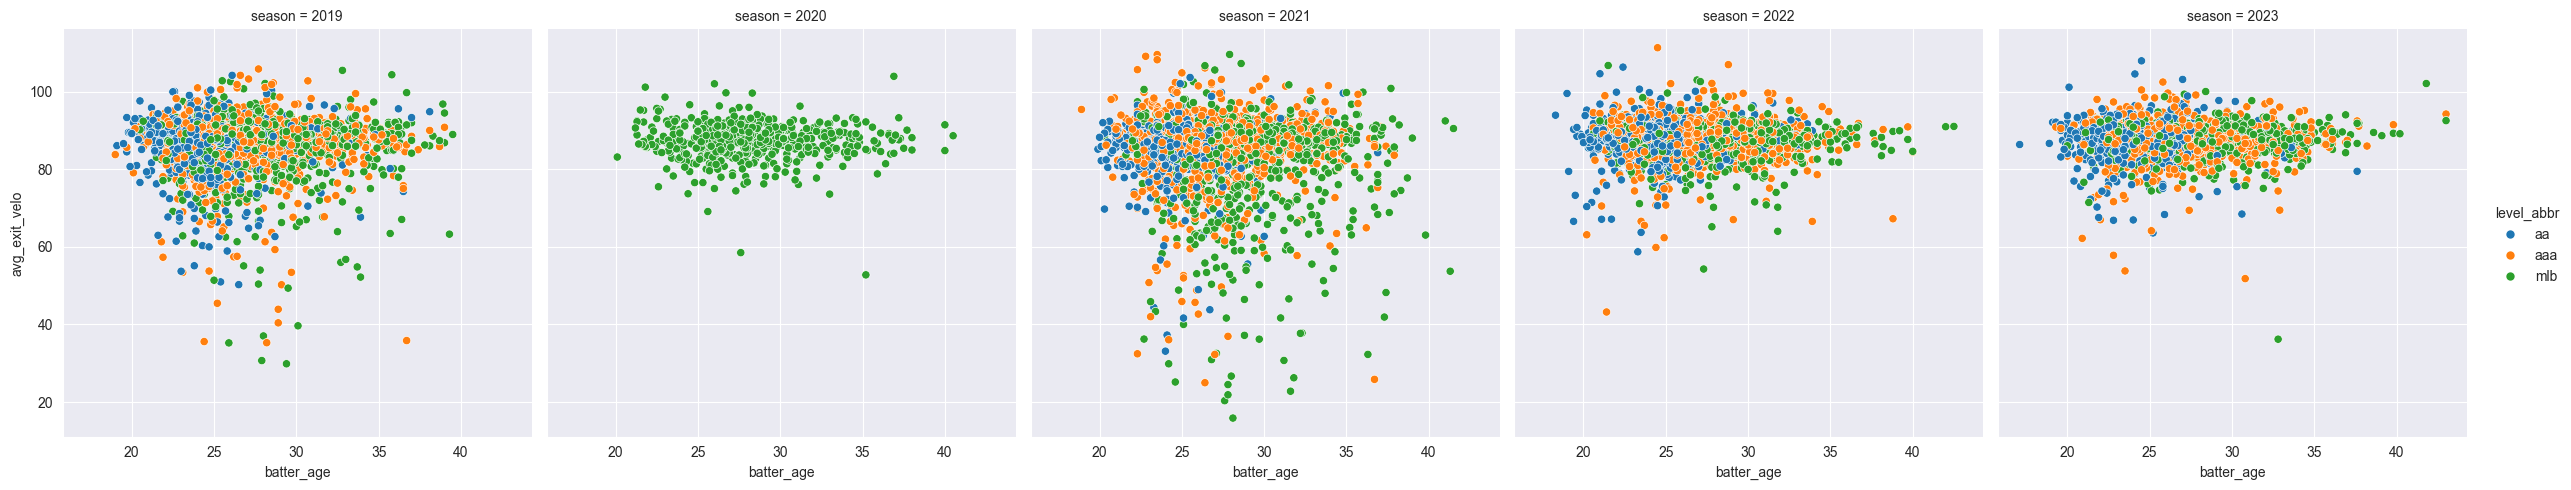

In [5]:
agg = df.groupby(['batter_id','season','level_abbr']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        batter_age=('age', 'mean'),
    ).reset_index()

sns.relplot(
    data=agg, x="batter_age", y="avg_exit_velo",
    col="season", hue="level_abbr",#, style="day",
    kind="scatter"
)

# No clear pattern in terms of age like a sweet spot, neither linear

<Axes: xlabel='batter_height', ylabel='avg_exit_velo'>

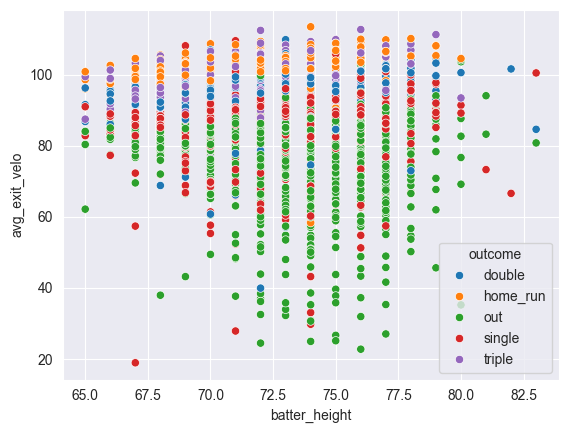

In [6]:
agg = df.groupby(['batter_id','outcome']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        batter_height=('batter_height', 'mean'),
    ).reset_index()


sns.scatterplot(data=agg, x="batter_height", y="avg_exit_velo", hue="outcome")

<Axes: xlabel='avg_hangtime', ylabel='avg_exit_velo'>

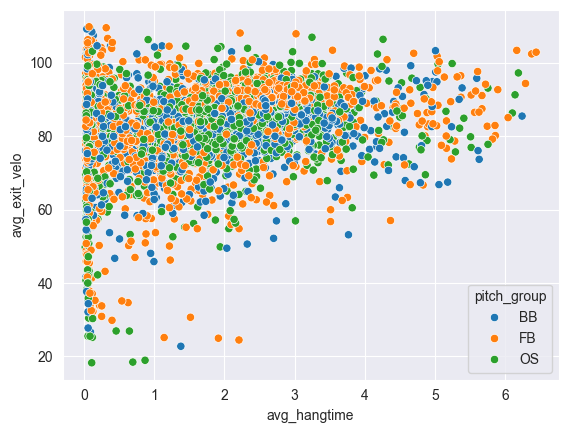

In [7]:
## Predictive variables
# 'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand', 'pitcher_hand', 'batter_height', 'pitch_group',  'age'
agg = df.groupby(['batter_id', 'pitch_group']).agg(
    events=('exit_velo', 'count'),
    avg_exit_velo=('exit_velo', 'mean'),
    sdev_exit_velo=('exit_velo', 'std'),
    avg_hangtime=('hangtime', 'mean'),
).reset_index()

sns.scatterplot(data=agg, x="avg_hangtime", y="avg_exit_velo", hue="pitch_group")

<Axes: xlabel='avg_hangtime', ylabel='avg_exit_velo'>

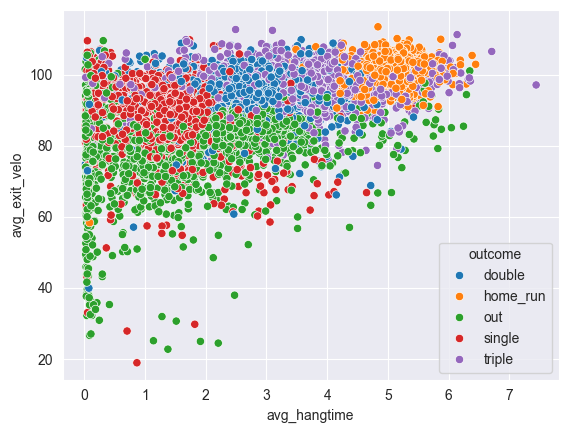

In [8]:
## Predictive variables
# 'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand', 'pitcher_hand', 'batter_height', 'pitch_group',  'age'
agg = df.groupby(['batter_id','outcome']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        avg_hangtime=('hangtime', 'mean'),
    ).reset_index()


sns.scatterplot(data=agg, x="avg_hangtime", y="avg_exit_velo", hue="outcome")
# interesting, home run had high av hang time, single and double had lower avg hand time

### Hand of pitcher and batter, match and not match case

In [26]:
import numpy as np
import pandas as pd

conditions = [
    (df['batter_hand'] == df['pitcher_hand'])
]
choices = ['SameHand']
df['handedness_matchup'] = np.select(conditions, choices, default='Other')

In [27]:
# As a NumPy array
arr = df['handedness_matchup'].values      # <-- no ()
# or
arr = df['handedness_matchup'].to_numpy()

# As a Python list
lst = df['handedness_matchup'].tolist()
lst

['SameHand',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'SameHand',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'Other',
 'Other',
 'Other',
 'SameHand',
 'Other',
 'SameHand',
 'SameHand',
 'SameHand',
 'SameHand',
 'S

In [28]:
df['handedness_matchup'] = pd.Categorical(
    df['handedness_matchup'],
    categories=['SameHand','PitcherR_BatterL','PitcherL_BatterR','Other'],
    ordered=True
)


/var/folders/93/h3g2jvn15rs8w2h9w6hcv55h0000gn/T/ipykernel_93887/3726199079.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['batter_id','handedness_matchup']).agg(


<Axes: xlabel='avg_launch_angle', ylabel='avg_exit_velo'>

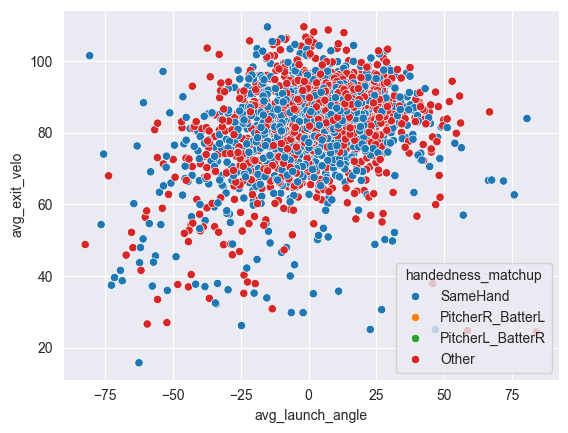

In [29]:
agg = df.groupby(['batter_id','handedness_matchup']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        avg_launch_angle=('launch_angle', 'mean'),
    ).reset_index()


sns.scatterplot(data=agg, x="avg_launch_angle", y="avg_exit_velo", hue="handedness_matchup")

<Axes: xlabel='handedness_matchup', ylabel='exit_velo'>

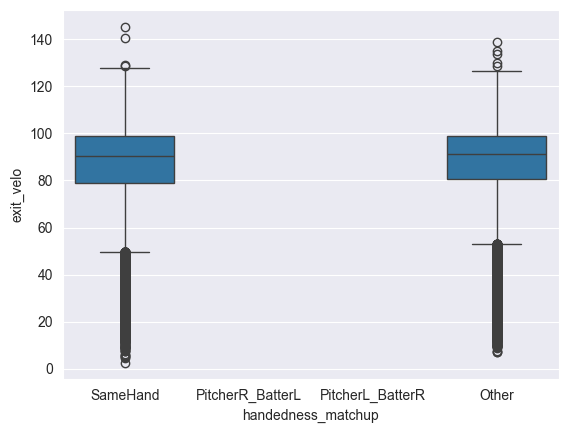

In [31]:
sns.boxplot(
    data=df, x="handedness_matchup", y="exit_velo"
)

In [16]:
df[df['handedness_matchup']=='Other'].groupby(['batter_hand','pitcher_hand']).count()

season  level_abbr  batter_id  pitcher_id  \
batter_hand pitcher_hand                                              
S           L              39097       39097      39097       39097   
            R             101514      101514     101514      101514   

                          exit_velo  launch_angle  spray_angle  hangtime  \
batter_hand pitcher_hand                                                   
S           L                 36335         38810        38869     36915   
            R                 94447        100889       101009     95965   

                          hit_type  batter_height  pitch_group  outcome  \
batter_hand pitcher_hand                                                  
S           L                39090          39097        39097    39097   
            R               101498         101514       101514   101514   

                             age  handedness_matchup  
batter_hand pitcher_hand                              
S           L              39097               39097  
            R             101514              101514

### Sweet spot as per launch angle and spray angle

<Axes: xlabel='avg_launch_angle', ylabel='avg_exit_velo'>

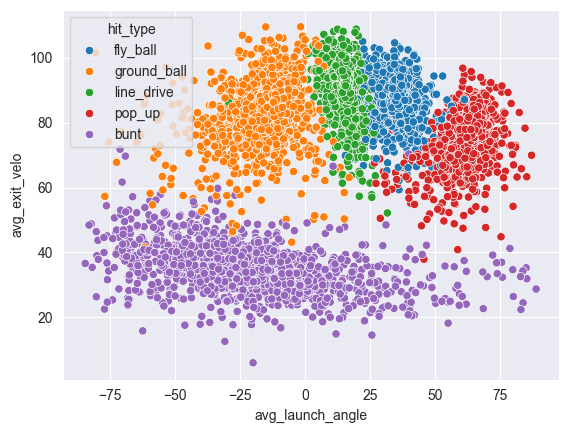

In [35]:
agg = df.groupby(['batter_id','hit_type']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        avg_launch_angle=('launch_angle', 'mean'),
    ).reset_index()


sns.scatterplot(data=agg, x="avg_launch_angle", y="avg_exit_velo", hue="hit_type")

<Axes: xlabel='avg_spray_angle', ylabel='avg_exit_velo'>

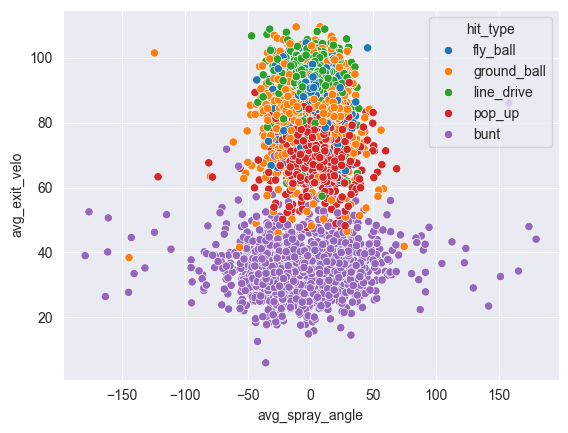

In [36]:
agg = df.groupby(['batter_id','hit_type']).agg(
        events=('exit_velo', 'count'),
        avg_exit_velo=('exit_velo', 'mean'),
        sdev_exit_velo=('exit_velo', 'std'),
        avg_spray_angle=('spray_angle', 'mean'),
    ).reset_index()


sns.scatterplot(data=agg, x="avg_spray_angle", y="avg_exit_velo", hue="hit_type")

In [39]:
df.columns

Index(['season', 'level_abbr', 'batter_id', 'pitcher_id', 'exit_velo',
       'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand',
       'pitcher_hand', 'batter_height', 'pitch_group', 'outcome', 'age'],
      dtype='object')

### Exploring categorical variables

<Axes: xlabel='outcome', ylabel='exit_velo'>

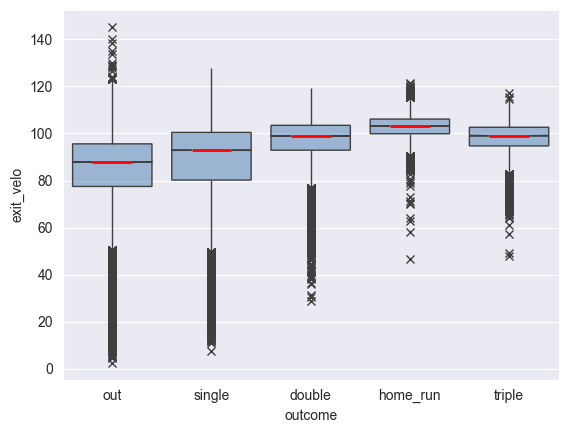

In [40]:
# outcome as a proxy to measure quality with exit_velocty, great that outcome is with highest median
sns.boxplot(
    data=df, x="outcome", y="exit_velo",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<Axes: xlabel='pitch_group', ylabel='exit_velo'>

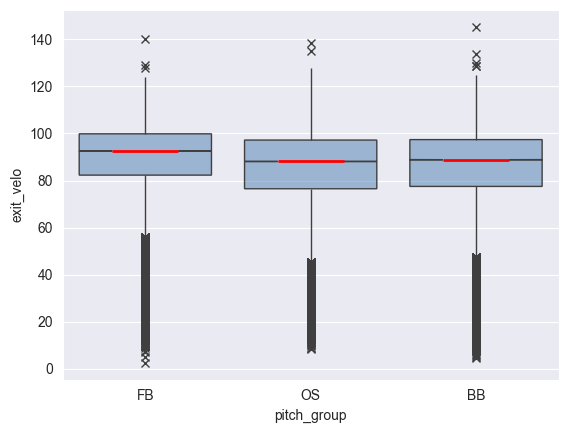

In [41]:
# pitch group case
sns.boxplot(
    data=df, x="pitch_group", y="exit_velo",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<Axes: xlabel='batter_hand', ylabel='exit_velo'>

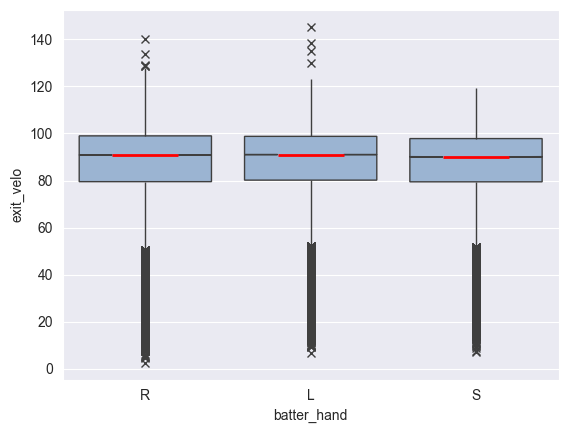

In [43]:
# batter_hand case, first view, does not seems to be significantly different in terms of exit_vel
sns.boxplot(
    data=df, x="batter_hand", y="exit_velo",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<Axes: xlabel='hit_type', ylabel='exit_velo'>

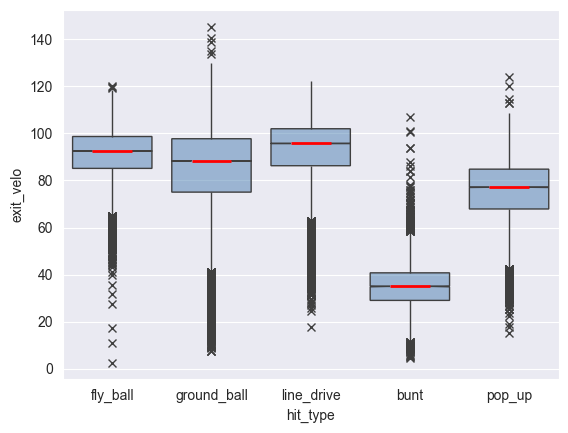

In [44]:
# hit_type case, bunt appart from other hit_type in terms of exit_vel
sns.boxplot(
    data=df, x="hit_type", y="exit_velo",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

In [45]:
data_dictionary = {
    "season": "Season of the observation",
    "level_abbr": "Level of competition (MLB, AAA, AA)",
    "batter_id": "ID of batter",
    "pitcher_id": "ID of pitcher",
    "exit_velo": "Exit velocity of batted ball in play",
    "launch_angle": "Vertical angle of batted ball in play",
    "spray_angle": "Horizontal angle of batted ball in play",
    "hangtime": "Hangtime of batted ball in play",
    "hit_type": "Hit type (bunt, fly ball, ground ball, line drive, pop up)",
    "batter_hand": "Batter handedness (Right, Left, Switch)",
    "pitcher_hand": "Pitcher handedness (Right, Left)",
    "batter_height": "Height of batter in inches",
    "pitch_group": "Grouped pitch type (Fastball, Breaking ball, Offspeed)",
    "outcome": "Outcome of batted ball in play (out, single, double, triple, home run)",
    "age": "Batter age that season, indexed to July 1"
}

In [46]:
## seasons and batters per season
df.groupby('season')['batter_id'].nunique()

season
2019    2140
2020     577
2021    2118
2022    1634
2023    1629
Name: batter_id, dtype: int64

In [127]:
# number of EVENTS per season
df.groupby('season')['batter_id'].count()

season
2019    126902
2020     46507
2021    123412
2022    125855
2023    126013
Name: batter_id, dtype: int64

In [128]:
# Number of batters
df['batter_id'].nunique()

1540

In [130]:
# batter exit velocity over time
batter_stats = df.groupby('batter_id')['exit_velo'].describe().reset_index()
batter_stats

,batter_id,count,mean,std,min,25%,50%,75%,max
0,2,20.0,92.340940,12.438868,65.7624,84.541400,96.32500,101.986550,107.5901
1,4,140.0,83.920064,13.646156,26.9702,76.455550,86.17505,93.715450,105.1161
2,6,790.0,87.559909,15.156187,28.1544,79.092650,91.57260,98.953325,109.9484
3,8,2.0,74.939800,0.057134,74.8994,74.919600,74.93980,74.960000,74.9802
4,11,73.0,88.300019,14.130239,27.2274,81.910200,92.89290,98.500000,108.6886
...,...,...,...,...,...,...,...,...,...
1535,4120,6.0,90.378717,14.329490,64.5849,86.798125,94.10535,100.130450,102.9755
1536,4121,33.0,73.304130,20.616967,25.4019,67.157900,77.78900,87.086500,103.2593
1537,4124,19.0,69.652711,25.132448,16.4235,48.960500,80.04030,85.315600,101.8190
1538,4125,16.0,85.981031,17.222138,50.7243,75.995300,92.35665,99.000300,106.8974


   batter_id  predicted_exit_velo  pred_std  pred_lower  pred_upper
0       2432            84.922929  1.943990   80.867989   88.669653
1       3814            84.944671  1.883575   81.134752   88.588967
2       3562            84.834976  1.925897   80.815759   88.548169
3        798            84.911261  1.960328   81.091470   89.119949
4       3798            84.607205  1.881018   81.069011   88.518103


In [70]:
print(df[df['batter_id']==3798],len(df[df['batter_id']==3798]), df[df['batter_id']==3798]['exit_velo'].mean())

        season level_abbr  batter_id  pitcher_id  exit_velo  launch_angle  \
128385    2022        mlb       3798        1358    70.0494    -12.704300   
128396    2022        mlb       3798        3292    97.6222     28.363200   
128408    2022        mlb       3798         877   100.0957      6.112000   
129880    2022        mlb       3798        2028    88.5640     57.933600   
131516    2022        mlb       3798         277   103.2897     17.157300   
...        ...        ...        ...         ...        ...           ...   
802551    2021        aaa       3798        3368    98.7466    -18.227800   
802560    2021        aaa       3798        1444    73.6714     -7.938200   
802587    2021        aaa       3798         119        NaN     65.736329   
803718    2021        aaa       3798         783   111.4025     11.489000   
803729    2021        aaa       3798         783   107.6246      0.690400   

        spray_angle  hangtime     hit_type batter_hand pitcher_hand  \
1283

In [71]:
df[df['batter_id']==3798].groupby(['batter_id','season','level_abbr'])['exit_velo'].describe().reset_index()

,batter_id,season,level_abbr,count,mean,std,min,25%,50%,75%,max
0,3798,2019,mlb,166.0,88.943295,15.919732,17.6158,77.101475,91.6364,102.647550,111.4319
1,3798,2020,mlb,83.0,87.897929,17.515306,35.4678,78.958850,94.2919,100.722550,111.5994
2,3798,2021,aaa,4.0,97.861275,16.976662,73.6714,92.477800,103.1856,108.569075,111.4025
3,3798,2021,mlb,37.0,87.250432,15.250765,50.8595,74.567800,86.9469,99.677600,111.8413
4,3798,2022,aaa,39.0,85.160844,19.087577,26.7878,74.029900,86.7600,101.195400,110.0445
5,3798,2022,mlb,84.0,86.015671,15.853888,28.2256,78.487975,88.7656,98.890375,109.6590


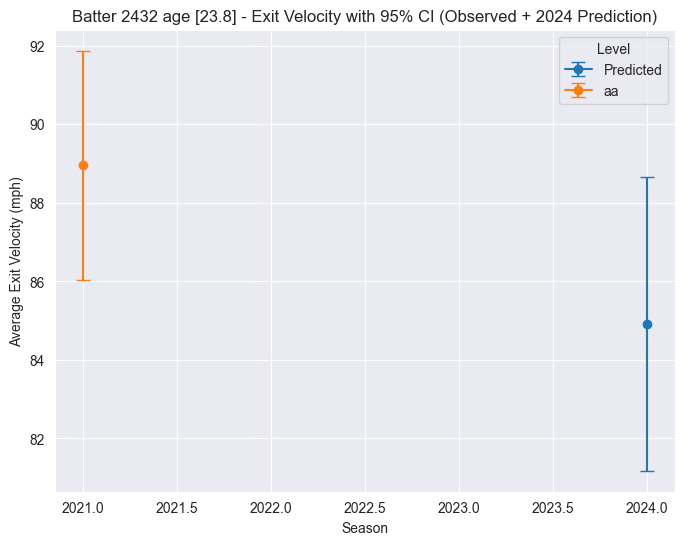

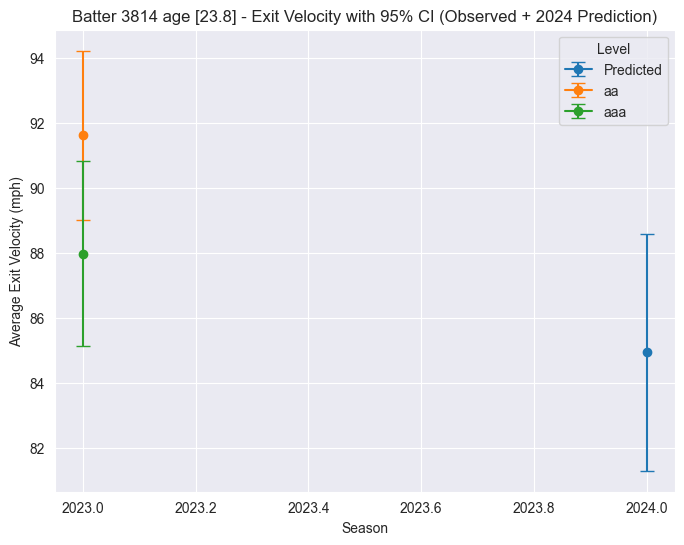

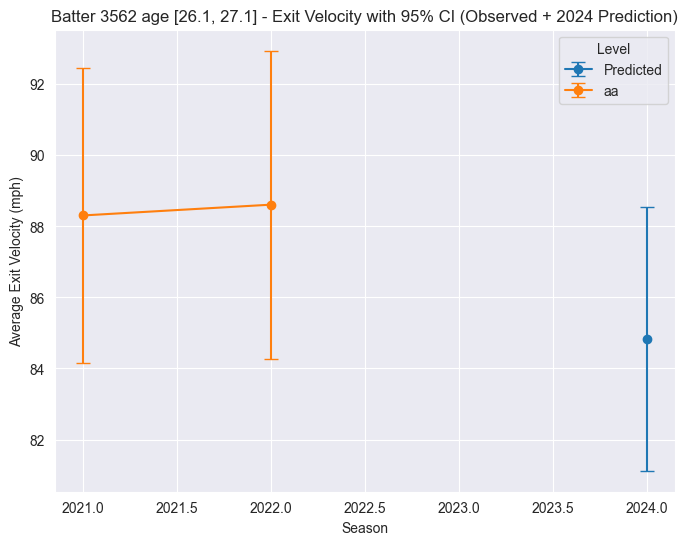

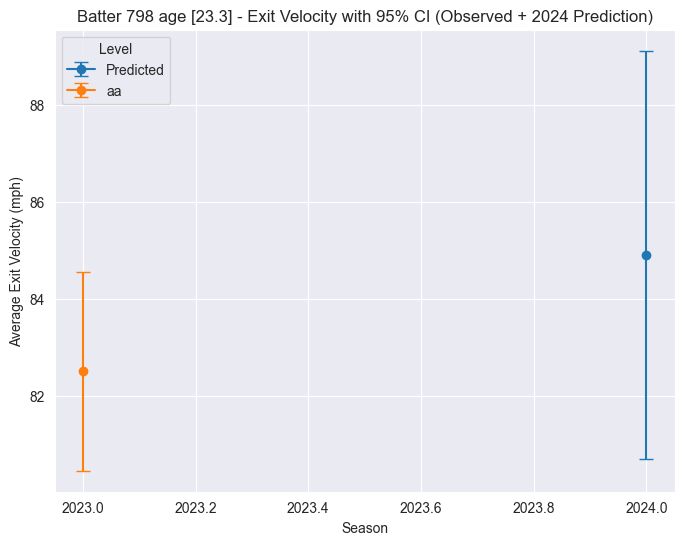

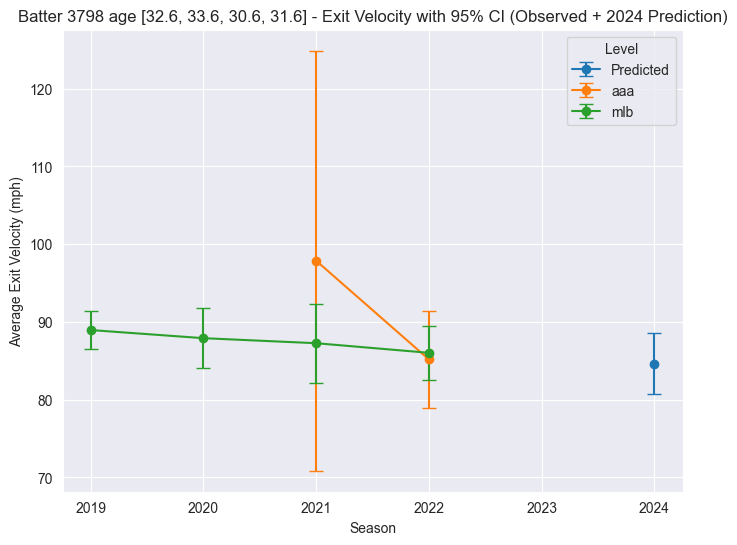

In [131]:
# batters with no events
len(batter_stats[batter_stats['count']<1]), batter_stats[batter_stats['count']<1]

(15,
       batter_id  count  mean  std  min  25%  50%  75%  max
 78          202    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 99          275    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 165         438    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 385        1076    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 440        1227    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 443        1236    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 490        1347    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 574        1565    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 670        1812    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 760        2078    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 859        2353    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 942        2555    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1070       2887    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1131       3039    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1491       4007    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN)

In [132]:
df[df['batter_id'].isin(batter_stats[batter_stats['count']<1]['batter_id'].values)].groupby(['outcome']).count()

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,age
outcome,,,,,,,,,,,,,,
out,17,17,17,17,0,7,7,0,16,17,17,17,17,17


In [133]:
df.groupby(['outcome']).count()

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,age
outcome,,,,,,,,,,,,,,
double,35875,35875,35875,35875,35775,35853,35853,35767,35875,35875,35875,35875,35875,35875
home_run,26559,26559,26559,26559,26528,26557,26557,26525,26559,26559,26559,26559,26559,26559
out,369463,369463,369463,369463,358482,368304,368305,358546,369434,369463,369463,369463,369463,369463
single,113719,113719,113719,113719,112506,113451,113452,112571,113690,113719,113719,113719,113719,113719
triple,3073,3073,3073,3073,3065,3069,3069,3065,3073,3073,3073,3073,3073,3073


In [135]:
df[df['batter_id']==6]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
394,2023,mlb,6,620,97.5291,8.7833,18.4558,1.3190,line_drive,R,L,72,BB,single,28.2
408,2023,mlb,6,3041,88.8571,24.5141,20.3835,3.7933,line_drive,R,R,72,BB,out,28.2
597,2023,mlb,6,620,79.4581,-3.6750,-37.9217,0.2618,ground_ball,R,L,72,FB,out,28.2
613,2023,mlb,6,620,76.5631,33.9603,-1.8987,4.3951,fly_ball,R,L,72,FB,out,28.2
622,2023,mlb,6,3041,75.5433,29.0082,17.7991,3.6652,line_drive,R,R,72,BB,out,28.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372513,2021,mlb,6,3089,99.6516,46.4625,21.4187,6.4142,fly_ball,R,R,72,BB,out,26.2
373582,2021,mlb,6,1370,78.0334,-33.6009,-54.5653,0.0336,ground_ball,R,L,72,OS,out,26.2
373596,2021,mlb,6,1450,100.3661,32.0385,-8.7987,5.7611,fly_ball,R,R,72,BB,home_run,26.2
373968,2021,mlb,6,3544,56.5729,8.4836,-4.1280,0.8563,ground_ball,R,R,72,FB,out,26.2


<Axes: >

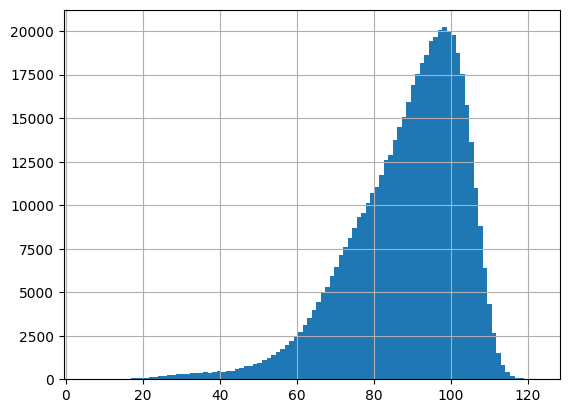

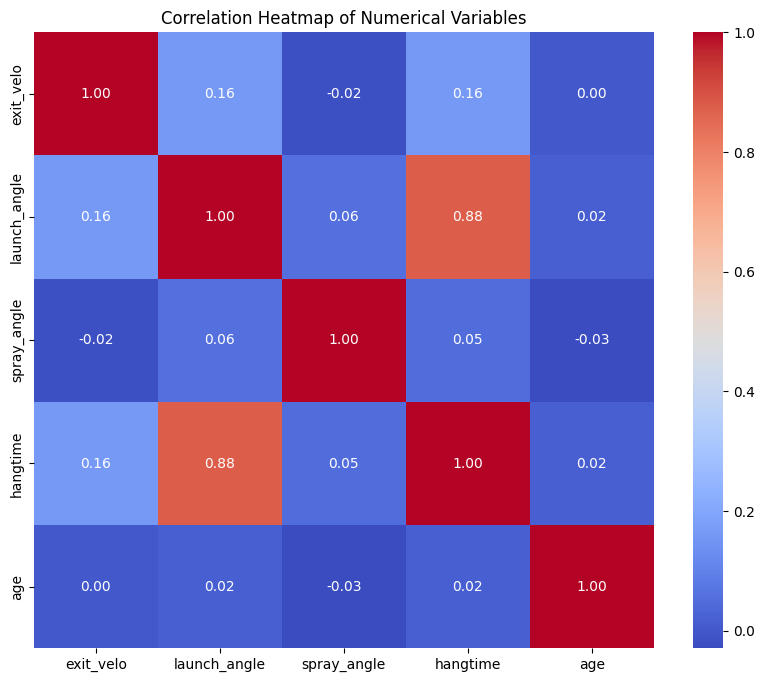

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_df = df.select_dtypes(include=['float64'])
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

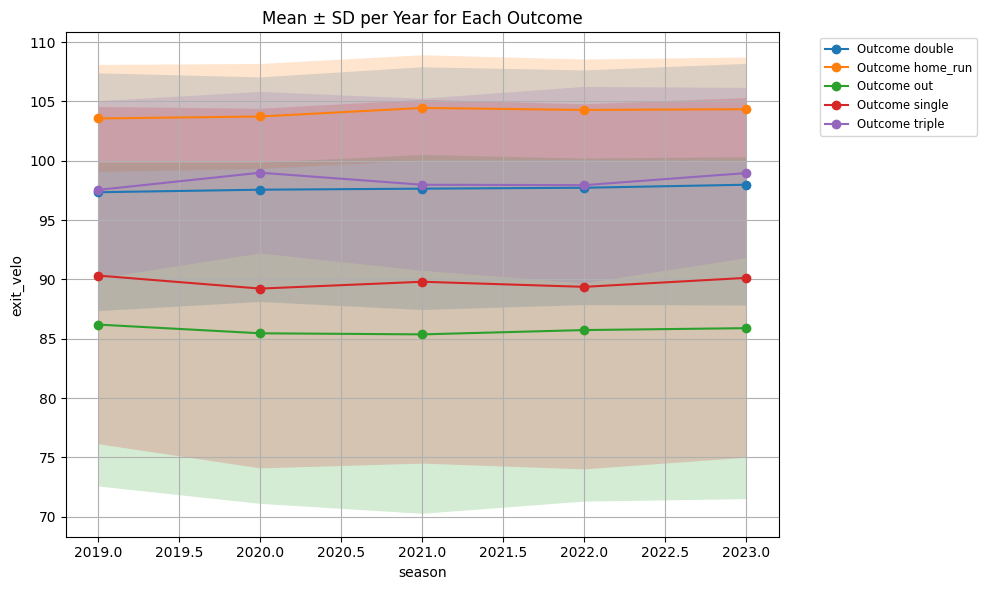

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df.groupby(["season", "outcome"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("outcome"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Outcome {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each Outcome")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


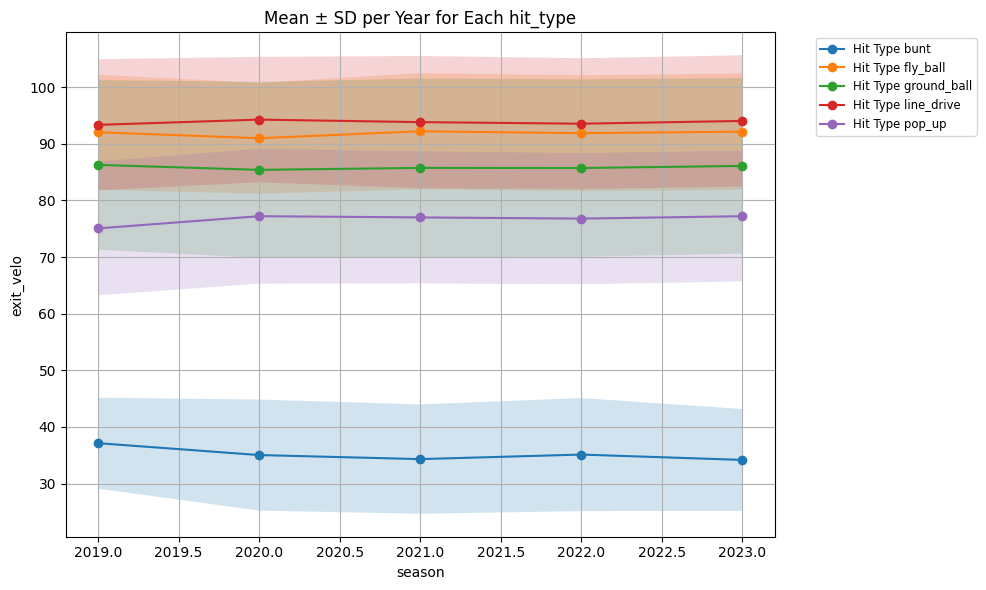

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df.groupby(["season", "hit_type"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("hit_type"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Hit Type {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each hit_type")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


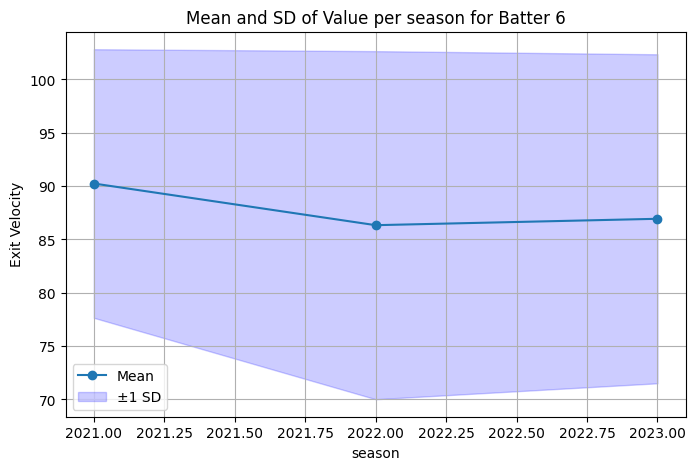

In [140]:
import pandas as pd
import matplotlib.pyplot as plt


stats = df[df['batter_id']==6].groupby("season")["exit_velo"].agg(["mean", "std"]).reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(stats["season"], stats["mean"], marker="o", label="Mean")
plt.fill_between(
    stats["season"],
    stats["mean"] - stats["std"],
    stats["mean"] + stats["std"],
    color="blue",
    alpha=0.2,
    label="±1 SD"
)
plt.xlabel("season")
plt.ylabel("Exit Velocity")
plt.title("Mean and SD of Value per season for Batter 6")
plt.legend()
plt.grid(True)
plt.show()


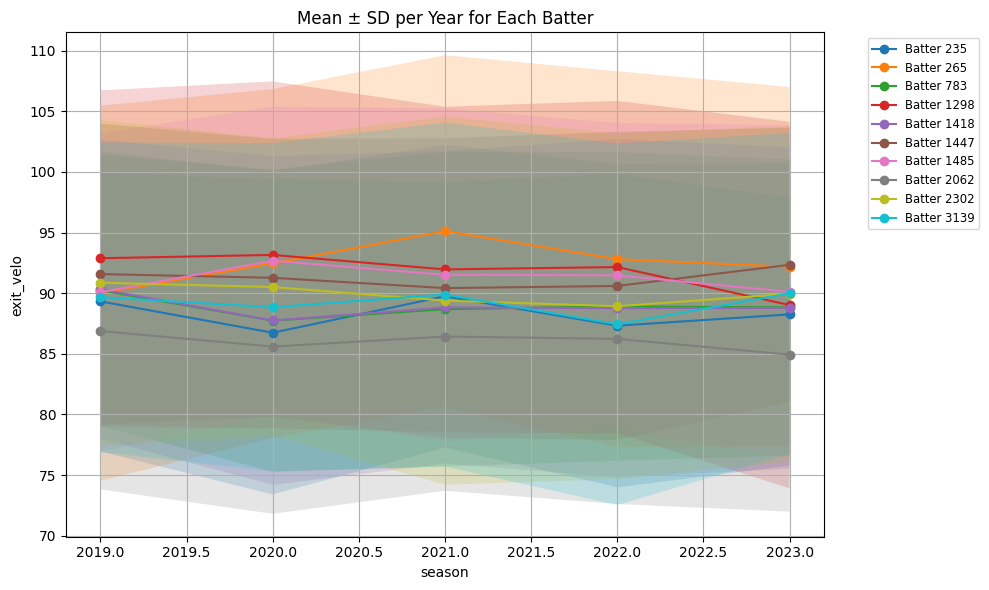

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df[df['batter_id'].isin([235,1485,2302,2062,3139,783,1447,265,1418,1298
])].groupby(["season", "batter_id"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("batter_id"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Batter {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each Batter")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


In [142]:
set(df.outcome)

{'double', 'home_run', 'out', 'single', 'triple'}

In [144]:
df[df['batter_id'].isin([235])]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
0,2023,mlb,235,1335,95.7352,47.236200,-6.442200,6.4960,fly_ball,R,R,72,FB,out,32.8
17,2023,mlb,235,1335,102.3143,6.828800,-21.681000,1.0272,ground_ball,R,R,72,BB,out,32.8
38,2023,mlb,235,436,93.3415,5.930500,14.926900,1.0638,ground_ball,R,R,72,FB,single,32.8
46,2023,mlb,235,2973,99.2878,24.902300,-17.505600,5.0018,fly_ball,R,R,72,FB,home_run,32.8
49,2023,mlb,235,1432,103.8804,-0.798800,-24.461800,0.3326,ground_ball,R,L,72,FB,out,32.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547650,2019,mlb,235,2906,86.2791,47.305300,-0.857000,5.6830,fly_ball,R,R,72,FB,out,28.8
547666,2019,mlb,235,2906,NaN,-29.644301,-1.022277,NaN,ground_ball,R,R,72,BB,single,28.8
547679,2019,mlb,235,2438,88.1097,78.436600,-25.106000,6.8022,pop_up,R,R,72,FB,out,28.8
548186,2019,mlb,235,2321,103.4463,33.654700,-7.715700,5.7864,fly_ball,R,R,72,FB,home_run,28.8


## First model approach

In [152]:
!pip install statsmodels

  Using cached statsmodels-0.14.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


In [155]:
df.columns

Index(['season', 'level_abbr', 'batter_id', 'pitcher_id', 'exit_velo',
       'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand',
       'pitcher_hand', 'batter_height', 'pitch_group', 'outcome', 'age'],
      dtype='object')

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I will do inference for a single clase of batter id with data for all seasons

all_seasons = set(df["season"].unique())

# Group by batter_id and check seasons
batters_all_seasons = (
    df.groupby("batter_id")["season"]
      .apply(lambda x: set(x.unique()) == all_seasons)
)

# Filter those batter_ids
valid_batters = batters_all_seasons[batters_all_seasons].index

# Subset dataset to only those batters
df_valid = df[df["batter_id"].isin(valid_batters)]
df_valid

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age,year
year,,,,,,,,,,,,,,,,
2023-01-01,2023,mlb,235,1335,95.7352,47.236200,-6.442200,6.4960,fly_ball,R,R,72,FB,out,32.8,2023-01-01
2023-01-01,2023,mlb,3182,1335,95.9380,4.729100,-4.805200,0.7806,ground_ball,L,R,75,OS,out,29.2,2023-01-01
2023-01-01,2023,mlb,3856,1988,89.1404,-16.225100,15.238200,0.0311,ground_ball,S,R,72,OS,out,29.7,2023-01-01
2023-01-01,2023,mlb,1594,1988,89.2888,0.507900,-22.189900,0.3802,ground_ball,R,R,73,FB,out,35.3,2023-01-01
2023-01-01,2023,mlb,1723,1335,68.7987,-39.227200,43.607500,0.0299,ground_ball,L,R,76,FB,out,28.0,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-01,2019,mlb,1058,2733,NaN,NaN,NaN,NaN,bunt,R,R,71,FB,out,25.1,2019-01-01
2019-01-01,2019,mlb,2424,2733,80.7754,33.744000,-9.085700,4.6743,fly_ball,R,R,70,FB,out,24.0,2019-01-01
2019-01-01,2019,mlb,2505,2733,NaN,63.635016,26.660205,NaN,pop_up,L,R,76,OS,out,33.6,2019-01-01


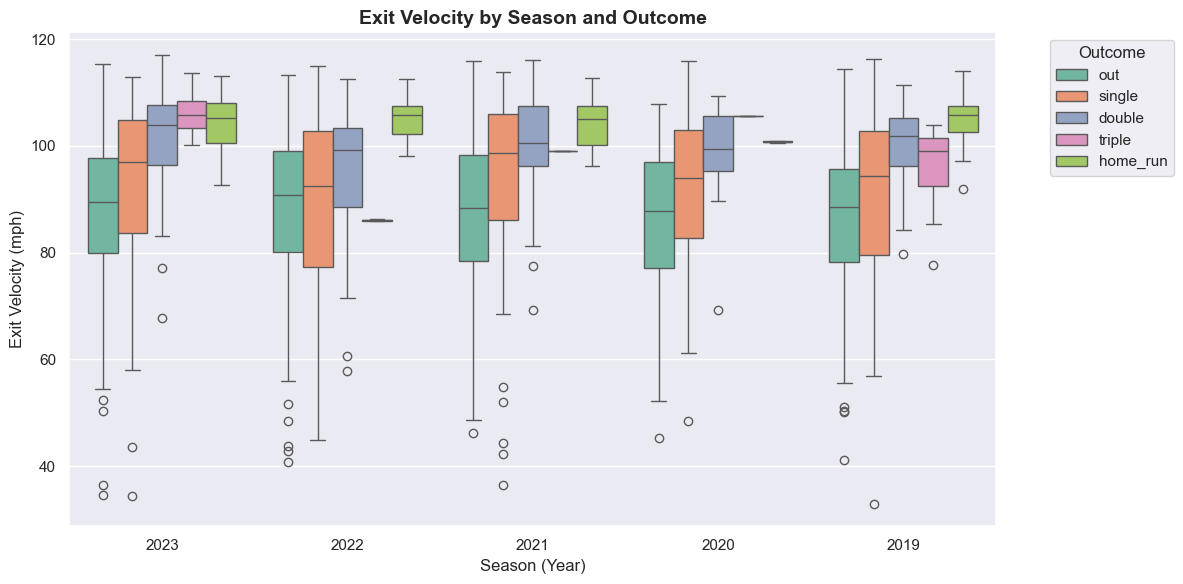

In [187]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

btc = (
    df.loc[df['batter_id'] == 3856, ['season', 'outcome', 'exit_velo','hit_type']]
      .dropna(subset=['season', 'outcome', 'exit_velo','hit_type'])
      .copy()
)

# Ensure columns are unique (paranoia check)
assert not btc.columns.duplicated().any(), "Duplicate column names detected."

# Make the index simple & unique
btc = btc.reset_index(drop=True)

# (Optional) normalize dtypes for categorical plotting
btc['season'] = btc['season'].astype(str)   # or .astype('category')
btc['outcome'] = btc['outcome'].astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=btc,
    x="season",
    y="exit_velo",
    hue="outcome",
    palette="Set2"
)
plt.title("Exit Velocity by Season and Outcome", fontsize=14, weight="bold")
plt.xlabel("Season (Year)", fontsize=12)
plt.ylabel("Exit Velocity (mph)", fontsize=12)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


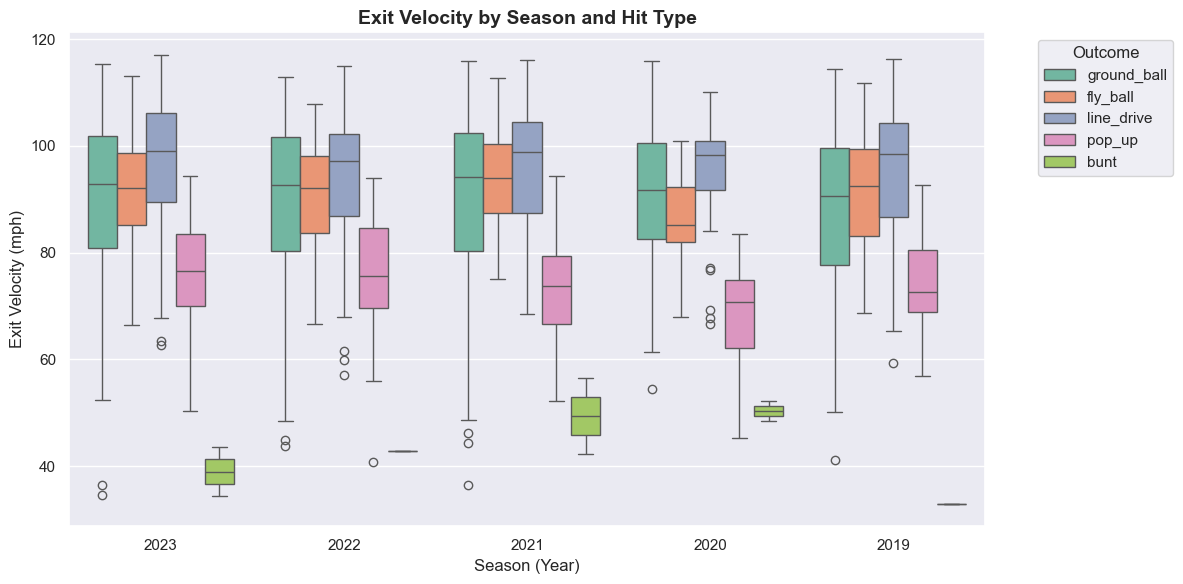

In [188]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Make the index simple & unique
btc = btc.reset_index(drop=True)

# (Optional) normalize dtypes for categorical plotting
btc['hit_type'] = btc['hit_type'].astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=btc,
    x="season",
    y="exit_velo",
    hue="hit_type",
    palette="Set2"
)
plt.title("Exit Velocity by Season and Hit Type", fontsize=14, weight="bold")
plt.xlabel("Season (Year)", fontsize=12)
plt.ylabel("Exit Velocity (mph)", fontsize=12)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


ImportError: cannot import name 'gaussian' from 'scipy.signal' (/Users/mariaoros/Library/Python/3.9/lib/python/site-packages/scipy/signal/__init__.py)